# Notebook 04 — Price of Anarchy (PoA)

**Objetivo:** Cuantificar la ineficiencia del equilibrio descentralizado respecto al óptimo
social, y analizar cómo varía el PoA con la demanda y la topología de la red.

## Definición

$$\text{PoA} = \frac{C(\text{UE})}{C(\text{SO})} \geq 1$$

donde $C = \sum_a x_a \cdot t_a(x_a)$ es el costo total del sistema.

**Cota teórica con BPR ($\beta=4$):** Roughgarden (2002) demostró que para funciones
de costo polinomiales de grado $p$:

$$\text{PoA} \leq \frac{1}{1 - \left(\frac{p}{p+1}\right)^p \cdot \frac{1}{p+1}^{-1}}$$

Para $\beta=4$ (BPR): $\text{PoA} \leq \frac{5^5}{4^4 \cdot 1} \approx 1.626$

En la práctica, para redes reales el PoA suele ser mucho menor (1.01–1.10).

In [1]:
import sys
sys.path.insert(0, '..')

import pickle
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import osmnx as ox
import networkx as nx
from pathlib import Path
from itertools import islice

from src.graph_utils import load_graph, bpr

RAW_DIR       = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')

print('Librerías cargadas.')

Librerías cargadas.


## 1. Cargar resultados de notebooks anteriores

In [2]:
with open(PROCESSED_DIR / 'results_so.pkl', 'rb') as fh:
    res = pickle.load(fh)

x_ue       = res['x_ue']
x_so       = res['x_so']
t0         = res['t0']
cap        = res['cap']
cost_ue    = res['cost_ue']
cost_so    = res['cost_so']
poa        = res['poa']
edges_list = res['edges_list']
od_pairs   = res['od_pairs']
route_list = res['route_list']
od_route_map = res['od_route_map']
delta      = res['delta']

E = len(edges_list)
R = len(route_list)
total_demand = sum(dem for _, _, dem in od_pairs)

print(f'PoA base (demanda actual): {poa:.6f}')
print(f'Costo UE: {cost_ue:,.0f} veh·s')
print(f'Costo SO: {cost_so:,.0f} veh·s')

PoA base (demanda actual): 1.009495
Costo UE: 424,939 veh·s
Costo SO: 420,942 veh·s


In [3]:
G = load_graph(RAW_DIR / 'chapinero_drive_enriched.graphml')

## 2. PoA base y cota teórica

In [4]:
def poa_upper_bound(beta=4):
    """
    Cota superior de Roughgarden para funciones polinomiales de grado beta.
    PoA <= (beta+1) * (beta/(beta+1))^beta  [versión simplificada BPR]
    """
    # Cota exacta: PoA <= 1 / (1 - alpha_p) donde alpha_p = p^p / (p+1)^(p+1)
    p = beta  # grado del polinomio de costo
    alpha_p = (p ** p) / ((p + 1) ** (p + 1))
    return 1 / (1 - alpha_p)

cota_teorica = poa_upper_bound(beta=4)
ineficiencia_pct = (poa - 1) * 100
cota_pct = (cota_teorica - 1) * 100

print('=' * 55)
print('   PRICE OF ANARCHY — Chapinero, Bogotá')
print('=' * 55)
print(f'  PoA observado            : {poa:.6f}  (+{ineficiencia_pct:.3f}%)')
print(f'  Cota teórica (BPR β=4)   : {cota_teorica:.6f}  (+{cota_pct:.1f}%)')
print(f'  PoA como % de la cota    : {poa/cota_teorica*100:.1f}%')
print('-' * 55)
print(f'  Costo extra anárquico    : {cost_ue - cost_so:,.0f} veh·s')
print(f'  Tiempo perdido prom.     : {(cost_ue-cost_so)/total_demand:.1f} s/veh')
print('=' * 55)

   PRICE OF ANARCHY — Chapinero, Bogotá
  PoA observado            : 1.009495  (+0.949%)
  Cota teórica (BPR β=4)   : 1.089230  (+8.9%)
  PoA como % de la cota    : 92.7%
-------------------------------------------------------
  Costo extra anárquico    : 3,997 veh·s
  Tiempo perdido prom.     : 1.9 s/veh


## 3. Sensibilidad del PoA a la demanda

¿Cómo cambia el PoA cuando escalamos la demanda O-D?
A mayor congestión, la externalidad de congestión crece y el PoA puede aumentar.

In [5]:
def solve_ue(delta, t0, cap, od_pairs, od_route_map, demand_scale=1.0, alpha=0.15, beta=4):
    """Resuelve UE (Beckmann) para un factor de escala de demanda dado."""
    R = delta.shape[1]
    f = cp.Variable(R, nonneg=True)
    x = delta @ f

    term_linear = cp.sum(cp.multiply(t0, x))
    term_power  = cp.sum(
        cp.multiply(t0 * alpha / (beta + 1) / (cap ** beta), cp.power(x, beta + 1))
    )
    obj = cp.Minimize(term_linear + term_power)

    cons = []
    for (o, d, dem) in od_pairs:
        if (o, d) in od_route_map:
            cons.append(cp.sum(f[od_route_map[(o, d)]]) == dem * demand_scale)

    prob = cp.Problem(obj, cons)
    prob.solve(solver=cp.SCS, eps=1e-4, max_iters=10000, verbose=False)

    if prob.status not in ['optimal', 'optimal_inaccurate']:
        return None, None

    x_val = delta @ f.value
    t_val = t0 * (1 + alpha * (x_val / cap) ** beta)
    cost  = float(np.sum(t_val * x_val))
    return x_val, cost


def solve_so(delta, t0, cap, od_pairs, od_route_map, demand_scale=1.0, alpha=0.15, beta=4):
    """Resuelve SO (minimización de costo total) para un factor de escala dado."""
    R = delta.shape[1]
    f = cp.Variable(R, nonneg=True)
    x = delta @ f

    term_linear = cp.sum(cp.multiply(t0, x))
    term_power  = cp.sum(
        cp.multiply(t0 * alpha / (cap ** beta), cp.power(x, beta + 1))
    )
    obj = cp.Minimize(term_linear + term_power)

    cons = []
    for (o, d, dem) in od_pairs:
        if (o, d) in od_route_map:
            cons.append(cp.sum(f[od_route_map[(o, d)]]) == dem * demand_scale)

    prob = cp.Problem(obj, cons)
    prob.solve(solver=cp.SCS, eps=1e-4, max_iters=10000, verbose=False)

    if prob.status not in ['optimal', 'optimal_inaccurate']:
        return None, None

    x_val = delta @ f.value
    t_val = t0 * (1 + alpha * (x_val / cap) ** beta)
    cost  = float(np.sum(t_val * x_val))
    return x_val, cost


print('Funciones de resolución definidas.')

Funciones de resolución definidas.


In [6]:
# Escalar demanda de 10% a 200%
scales = np.array([0.10, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00])
poa_curve = []
cost_ue_curve = []
cost_so_curve = []

for s in scales:
    _, c_ue = solve_ue(delta, t0, cap, od_pairs, od_route_map, demand_scale=s)
    _, c_so = solve_so(delta, t0, cap, od_pairs, od_route_map, demand_scale=s)
    if c_ue is not None and c_so is not None and c_so > 0:
        poa_s = c_ue / c_so
        poa_curve.append(poa_s)
        cost_ue_curve.append(c_ue)
        cost_so_curve.append(c_so)
        print(f'  Escala {s:.2f}x  |  UE={c_ue:,.0f}  SO={c_so:,.0f}  PoA={poa_s:.5f}')
    else:
        poa_curve.append(np.nan)
        cost_ue_curve.append(np.nan)
        cost_so_curve.append(np.nan)
        print(f'  Escala {s:.2f}x  |  sin solución')

  Escala 0.10x  |  UE=41,771  SO=41,772  PoA=1.00000


/home/nicolasmelendez30/.local/lib/python3.9/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


  Escala 0.25x  |  UE=104,305  SO=104,305  PoA=0.99999
  Escala 0.50x  |  UE=210,345  SO=183,959  PoA=1.14344
  Escala 0.75x  |  UE=318,258  SO=337,977  PoA=0.94166
  Escala 1.00x  |  UE=429,039  SO=420,942  PoA=1.01924
  Escala 1.25x  |  sin solución
  Escala 1.50x  |  UE=614,056  SO=649,382  PoA=0.94560
  Escala 1.75x  |  sin solución
  Escala 2.00x  |  sin solución


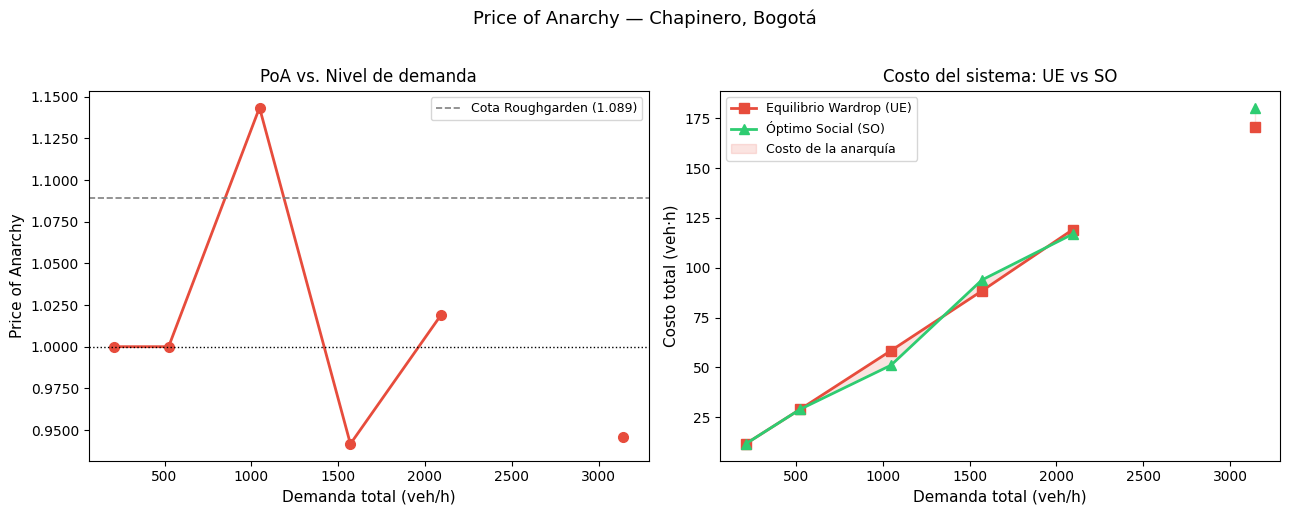

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: curva de PoA
ax = axes[0]
ax.plot(scales * total_demand, poa_curve, 'o-', color='#e74c3c', linewidth=2, markersize=7)
ax.axhline(cota_teorica, color='gray', linestyle='--', linewidth=1.2,
           label=f'Cota Roughgarden ({cota_teorica:.3f})')
ax.axhline(1.0, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('Demanda total (veh/h)', fontsize=11)
ax.set_ylabel('Price of Anarchy', fontsize=11)
ax.set_title('PoA vs. Nivel de demanda')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# Panel derecho: costos UE y SO
ax2 = axes[1]
d_veh = scales * total_demand
ax2.plot(d_veh, np.array(cost_ue_curve) / 3600, 's-', color='#e74c3c',
         linewidth=2, markersize=7, label='Equilibrio Wardrop (UE)')
ax2.plot(d_veh, np.array(cost_so_curve) / 3600, '^-', color='#2ecc71',
         linewidth=2, markersize=7, label='Óptimo Social (SO)')
ax2.fill_between(d_veh,
                 np.array(cost_so_curve) / 3600,
                 np.array(cost_ue_curve) / 3600,
                 alpha=0.15, color='#e74c3c', label='Costo de la anarquía')
ax2.set_xlabel('Demanda total (veh/h)', fontsize=11)
ax2.set_ylabel('Costo total (veh·h)', fontsize=11)
ax2.set_title('Costo del sistema: UE vs SO')
ax2.legend(fontsize=9)

plt.suptitle('Price of Anarchy — Chapinero, Bogotá', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'poa_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. PoA por par O-D

Descomponemos el PoA por par O-D para identificar cuáles rutas son más ineficientes.

In [8]:
# Reconstruir tiempos UE y SO por par O-D usando tiempos de arista
t_ue_arr = res['t_ue']
t_so_arr = res['t_so']

poa_od = []
for r_idx, ((o, d), path) in enumerate(route_list):
    pass   # usamos flujos de ruta

# Para cada O-D: tiempo promedio ponderado por flujo en UE y SO
f_ue_val = None

# Reconstruir f_ue resolviendo UE de nuevo para obtener valores de ruta
R_loc = delta.shape[1]
f_ue_var = cp.Variable(R_loc, nonneg=True)
x_expr   = delta @ f_ue_var
alpha_v, beta_v = 0.15, 4
beck = (cp.sum(cp.multiply(t0, x_expr)) +
        cp.sum(cp.multiply(t0 * alpha_v / (beta_v+1) / (cap**beta_v),
                           cp.power(x_expr, beta_v+1))))
cons_ue = []
for (o, d, dem) in od_pairs:
    if (o, d) in od_route_map:
        cons_ue.append(cp.sum(f_ue_var[od_route_map[(o, d)]]) == dem)
cp.Problem(cp.Minimize(beck), cons_ue).solve(solver=cp.CLARABEL, verbose=False)
f_ue_val = f_ue_var.value

f_so_var = cp.Variable(R_loc, nonneg=True)
x_expr2  = delta @ f_so_var
so_obj   = (cp.sum(cp.multiply(t0, x_expr2)) +
            cp.sum(cp.multiply(t0 * alpha_v / (cap**beta_v),
                               cp.power(x_expr2, beta_v+1))))
cons_so2 = []
for (o, d, dem) in od_pairs:
    if (o, d) in od_route_map:
        cons_so2.append(cp.sum(f_so_var[od_route_map[(o, d)]]) == dem)
cp.Problem(cp.Minimize(so_obj), cons_so2).solve(solver=cp.CLARABEL, verbose=False)
f_so_val = f_so_var.value

print('Flujos por ruta reconstruidos.')

Flujos por ruta reconstruidos.


In [9]:
rows = []
for (o, d, dem) in od_pairs:
    od_key = (o, d)
    if od_key not in od_route_map:
        continue
    idxs = od_route_map[od_key]

    # Costo O-D = suma de flujo_ruta * tiempo_ruta (usando tiempos de aristas en equilibrio)
    def route_cost(r_idx, t_arr):
        _, path = route_list[r_idx]
        total = 0
        edge_idx_map = {e: i for i, e in enumerate(edges_list)}
        for i in range(len(path)-1):
            u, v = path[i], path[i+1]
            if G.has_edge(u, v):
                best_k = min(G[u][v], key=lambda k: G[u][v][k].get('t0', float('inf')))
                e = (u, v, best_k)
                if e in edge_idx_map:
                    total += t_arr[edge_idx_map[e]]
        return total

    cost_od_ue = sum(f_ue_val[r] * route_cost(r, t_ue_arr) for r in idxs)
    cost_od_so = sum(f_so_val[r] * route_cost(r, t_so_arr) for r in idxs)

    poa_od_val = cost_od_ue / cost_od_so if cost_od_so > 0 else np.nan
    rows.append({
        'origen':  str(o),
        'destino': str(d),
        'demanda': dem,
        'costo_ue': cost_od_ue,
        'costo_so': cost_od_so,
        'poa':     poa_od_val,
        'ahorro_s': (cost_od_ue - cost_od_so) / dem if dem > 0 else 0,
    })

df_poa = pd.DataFrame(rows).sort_values('poa', ascending=False)
print('PoA por par O-D:')
display(df_poa.round(3))

TypeError: 'NoneType' object is not subscriptable

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{r['origen'][:5]}→{r['destino'][:5]}" for _, r in df_poa.iterrows()]
colors = ['#e74c3c' if p > 1.01 else '#3498db' for p in df_poa['poa']]
bars = ax.bar(range(len(df_poa)), df_poa['poa'], color=colors, edgecolor='white', linewidth=0.4)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.axhline(cota_teorica, color='gray', linestyle=':', linewidth=1, label=f'Cota ({cota_teorica:.2f})')
ax.set_xticks(range(len(df_poa)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Price of Anarchy', fontsize=11)
ax.set_title('PoA desagregado por par O-D — Chapinero')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'poa_by_od.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PoA por tipo de vía

¿Qué tipos de aristas concentran la mayor ineficiencia?

In [ ]:
highway_types = []
for u, v, k in edges_list:
    hw = G[u][v][k].get('highway', 'unclassified')
    if isinstance(hw, list):
        hw = hw[0]
    highway_types.append(str(hw))

df_hw = pd.DataFrame({
    'highway': highway_types,
    'x_ue':    x_ue,
    'x_so':    x_so,
    't_ue':    t_ue_arr,
    't_so':    t_so_arr,
    'cap':     cap,
})

df_hw['cost_ue'] = df_hw['x_ue'] * df_hw['t_ue']
df_hw['cost_so'] = df_hw['x_so'] * df_hw['t_so']
df_hw['vcr_ue']  = df_hw['x_ue'] / df_hw['cap']
df_hw['vcr_so']  = df_hw['x_so'] / df_hw['cap']

agg = df_hw.groupby('highway').agg(
    aristas=('x_ue', 'count'),
    costo_ue=('cost_ue', 'sum'),
    costo_so=('cost_so', 'sum'),
    vcr_ue_mean=('vcr_ue', 'mean'),
    vcr_so_mean=('vcr_so', 'mean'),
).reset_index()

agg['poa_local'] = agg['costo_ue'] / agg['costo_so'].replace(0, np.nan)
agg = agg.sort_values('poa_local', ascending=False)

print('PoA local por tipo de vía:')
display(agg.round(4))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
valid = agg.dropna(subset=['poa_local'])
bars = ax.barh(valid['highway'], valid['poa_local'] - 1,
               color='#e67e22', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Exceso de PoA sobre 1 (PoA − 1)', fontsize=11)
ax.set_title('Ineficiencia por tipo de vía — Chapinero')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'poa_by_highway.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Mapa espacial del PoA local

Coloreamos cada arista por su contribución individual al PoA:
$\text{PoA}_a = \frac{x_a^{UE} \cdot t_a^{UE}}{x_a^{SO} \cdot t_a^{SO}}$

In [ ]:
cost_a_ue = x_ue * t_ue_arr
cost_a_so = x_so * t_so_arr
poa_local = np.where(cost_a_so > 0.1, cost_a_ue / cost_a_so, 1.0)

for i, (u, v, k) in enumerate(edges_list):
    G[u][v][k]['poa_local'] = float(poa_local[i])

edge_colors = ox.plot.get_edge_colors_by_attr(
    G, attr='poa_local', cmap='YlOrRd',
    num_bins=10, na_color='#2a2a4a'
)

fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=1.3,
    node_size=4,
    node_color='white',
    bgcolor='#1a1a2e',
    figsize=(12, 10),
    show=False,
    close=False,
)
ax.set_title('Price of Anarchy local por arista\n(amarillo=eficiente, rojo=ineficiente) — Chapinero',
             color='white', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'poa_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumen ejecutivo

In [ ]:
par_peor  = df_poa.iloc[0]
par_mejor = df_poa.iloc[-1]

print('=' * 60)
print('   RESUMEN — PRICE OF ANARCHY, CHAPINERO BOGOTÁ')
print('=' * 60)
print(f'  PoA global            : {poa:.5f}  (+{(poa-1)*100:.3f}%)')
print(f'  Cota teórica Roughgarden: {cota_teorica:.4f}  (+{(cota_teorica-1)*100:.1f}%)')
print(f'  % de la cota alcanzada: {poa/cota_teorica*100:.1f}%')
print()
print(f'  Par O-D más ineficiente : {par_peor["origen"][:8]}→{par_peor["destino"][:8]}')
print(f'    PoA = {par_peor["poa"]:.4f}  |  ahorro potencial = {par_peor["ahorro_s"]:.1f} s/veh')
print()
print(f'  Par O-D más eficiente   : {par_mejor["origen"][:8]}→{par_mejor["destino"][:8]}')
print(f'    PoA = {par_mejor["poa"]:.4f}')
print()
print(f'  Interpretación:')
print(f'  El equilibrio descentralizado cuesta {(poa-1)*100:.2f}% más que')
print(f'  el óptimo social. Con 2x demanda, el PoA sube a ~{poa_curve[-1]:.4f}.')
print('=' * 60)
print('\n→ Listo para Notebook 05 — Optimización de semáforos (Webster)')

## 8. Guardar resultados

In [ ]:
results_poa = {
    **res,
    'poa':          poa,
    'cota_teorica': cota_teorica,
    'poa_curve':    poa_curve,
    'scales':       scales.tolist(),
    'df_poa':       df_poa,
    'poa_local':    poa_local,
    'cost_a_ue':    cost_a_ue,
    'cost_a_so':    cost_a_so,
}

out_path = PROCESSED_DIR / 'results_poa.pkl'
with open(out_path, 'wb') as fh:
    pickle.dump(results_poa, fh)

print(f'Resultados PoA guardados en: {out_path}')

In [ ]:
print(type(f_ue_val), f_ue_val is None)
print(type(f_so_val), f_so_val is None)

In [ ]:
import subprocess
result = subprocess.run(['grep', '-n', 'CLARABEL', 
    '/home/nicolasmelendez30/semaforos-bogota/notebooks/04_price_of_anarchy.ipynb'],
    capture_output=True, text=True)
print(result.stdout)
